URDFファイルを ./robots/simple_arm_dof3.urdf に保存しました。自由度: 3
URDFファイルを ./robots/simple_arm_dof3.urdf に保存しました。自由度: 3
Angle Limits: [-3.14 -3.14 -3.14], [3.14 3.14 3.14]
Velocity Limits: -[15.70796327 15.70796327 15.70796327], [15.70796327 15.70796327 15.70796327]
Effort Limits: -[31.41592654 31.41592654 31.41592654], [31.41592654 31.41592654 31.41592654]


INFO:2025-12-04 03:33:42,135:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-12-04 03:33:42,135 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


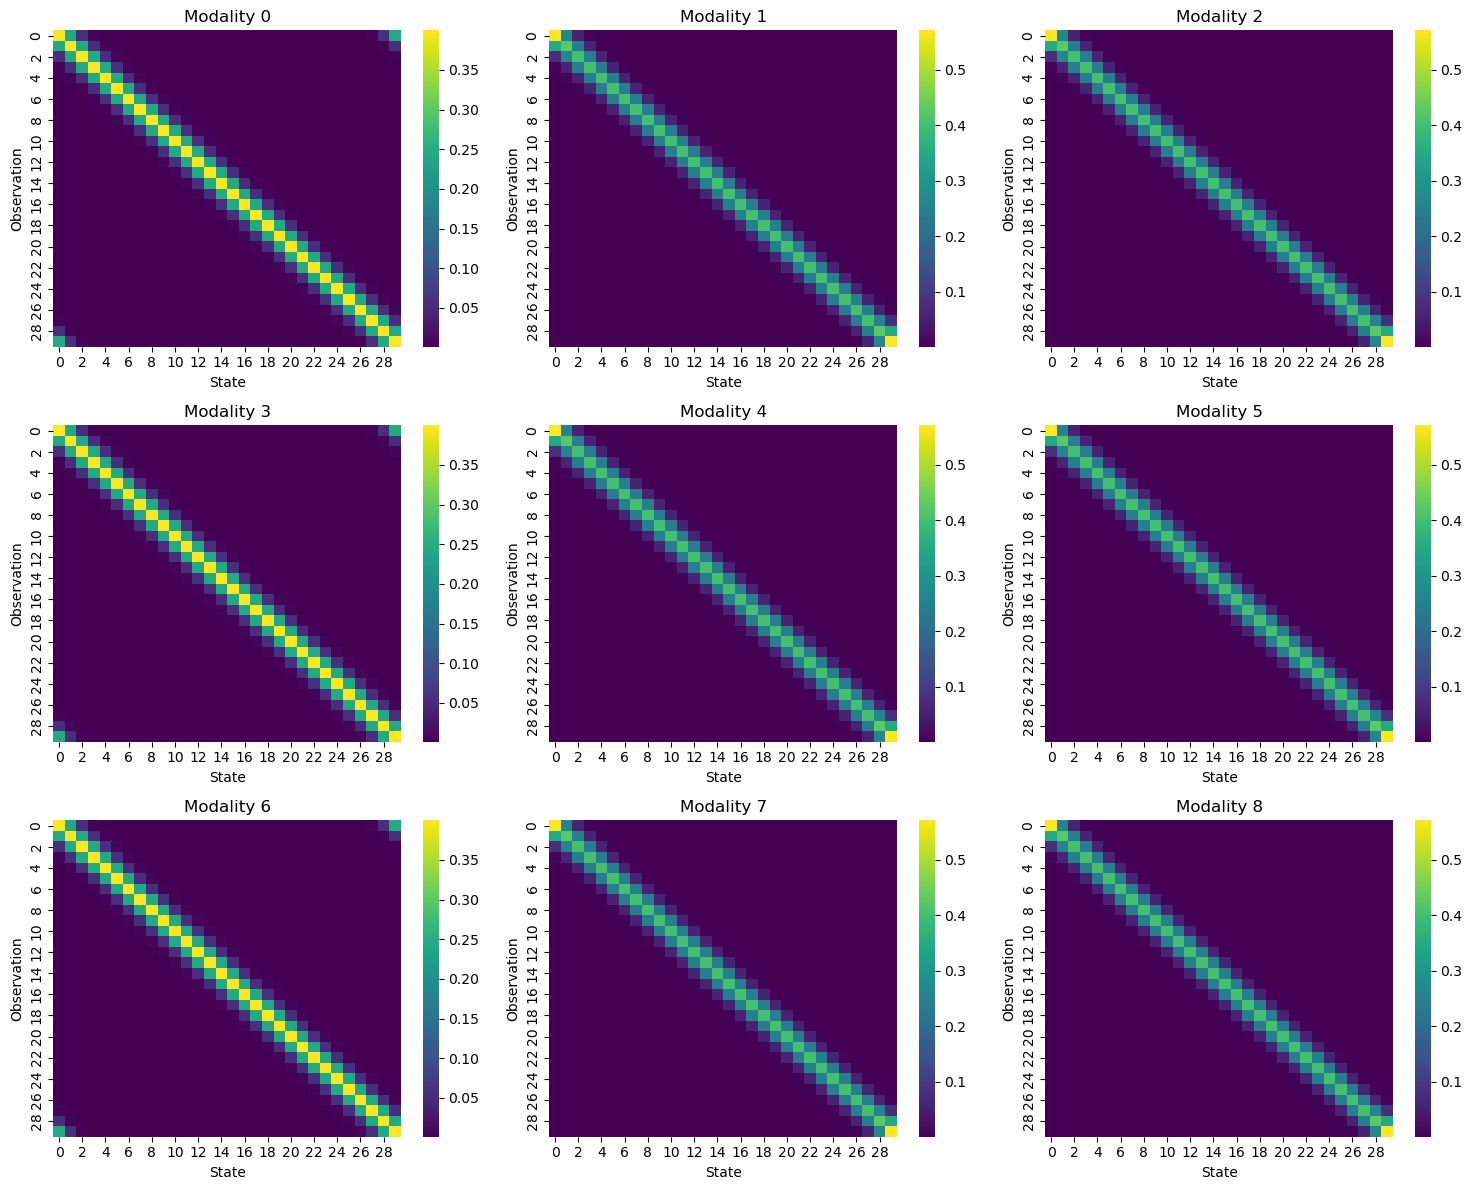

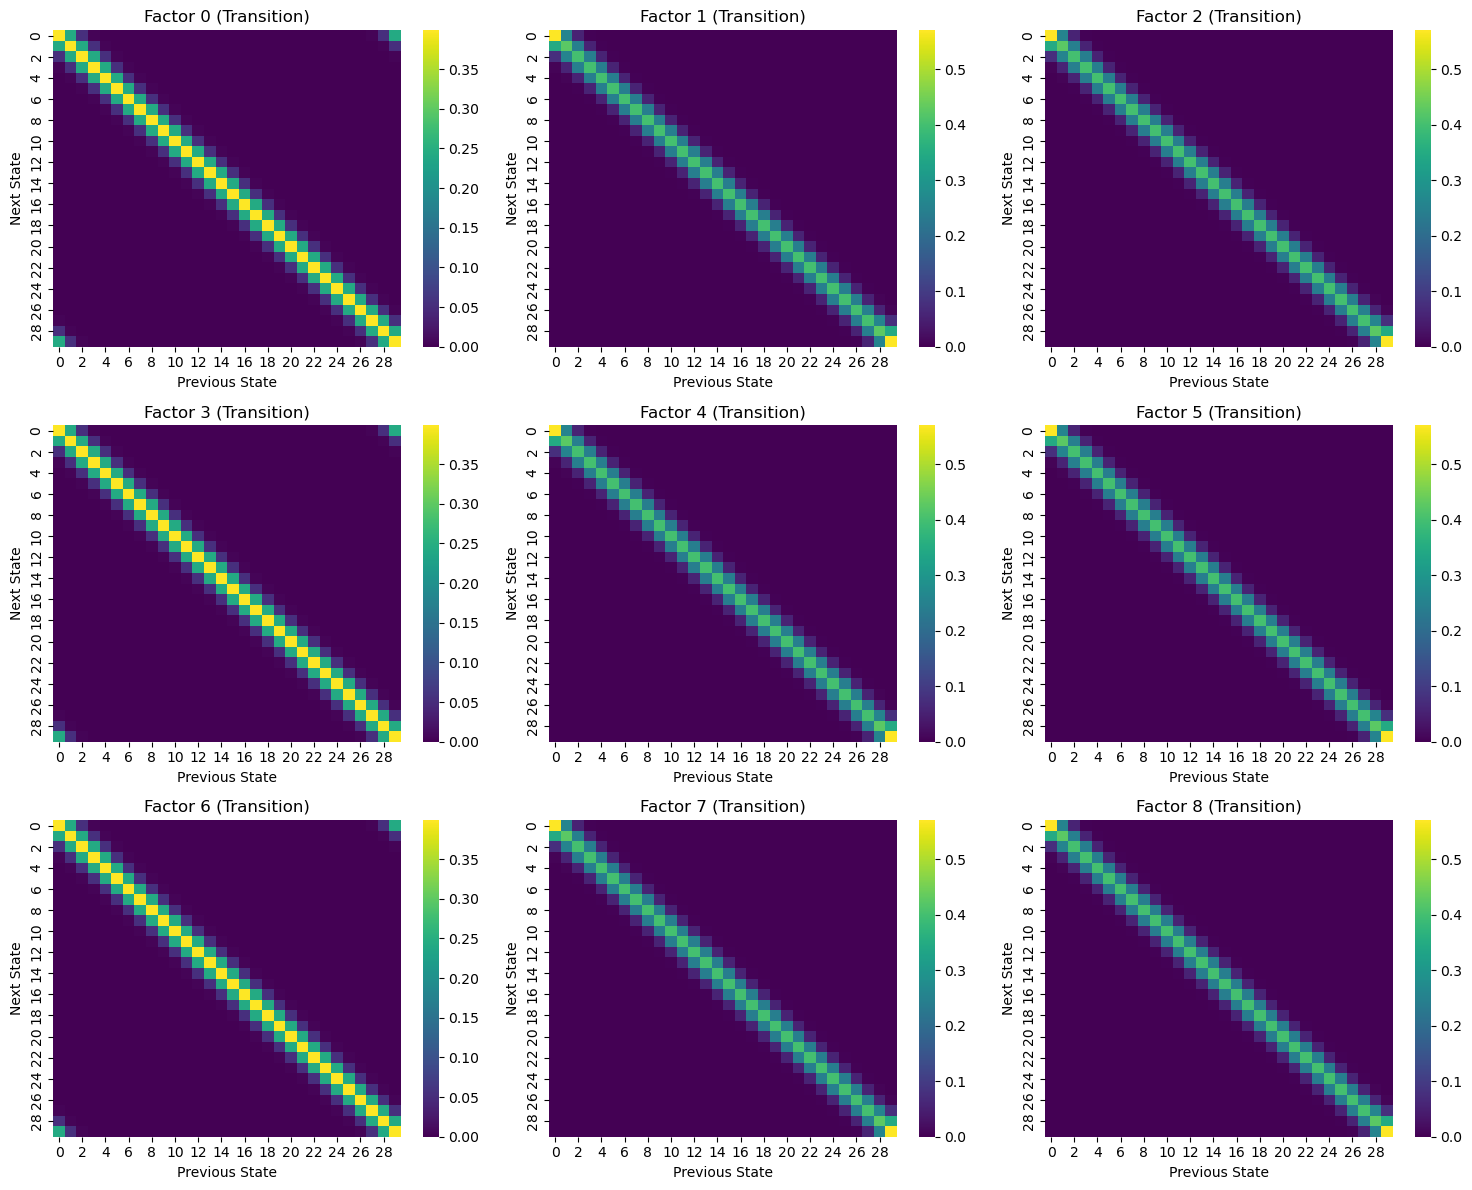

time_steps: 150, dt: 0.03333333333333333
収束しました！ iteration: 23
収束しました！ iteration: 23
param set in (13.11sec)
optimizer initialized in 0.00sec
const_beliefs generaeted in 0.00sec
cconst_beliefs set in 57.90sec


In [ ]:
import sys
import os
import time

Ts = time.time()

# notebooks/ から見た src のパスを追加
sys.path.append(os.path.abspath("../src"))

# sys.path.append(os.path.abspath("../yglab/pymdp"))

# 自作パッケージを import
from sim_utils import *
import pymdp

# optimizerの準備
# モデル・データ読み込み
dof = 3
model = get_simple_arm(dof=dof)  # 自分のURDFを読み込むなら buildModelFromUrdf
data = model.createData()

velocity_scale = 5.0
effort_scale = 10.0

model.velocityLimit = np.full(dof, np.pi * velocity_scale)
model.effortLimit = np.full(dof, np.pi * effort_scale)
print(f"Angle Limits: {model.lowerPositionLimit}, {model.upperPositionLimit}")
print(f"Velocity Limits: -{model.velocityLimit}, {model.velocityLimit}")
print(f"Effort Limits: -{model.effortLimit}, {model.effortLimit}")

# エージェントの準備
bin_M = 30
# よさげなセット。ただし右肩下がりがあまり見られないのと、vfe小さい領域でkldが大きくならない
# eps = 0.01
# var_a = 1/bin_M *3
# var_b = 1/bin_M *6

eps = 1.0e-3 # 1.0e-3が先行研究
var_a = 1/bin_M 
var_b = 1/bin_M
num_iter = 16

num_obs = [bin_M for _ in range(dof*3)]
agent = RobotPerceptor(
    num_obs = num_obs,
    # num_obs=[10,10,10, 10,10,10, 10,10,10],
    # num_obs=[15, 15, 15, 15, 15, 15, 15, 15, 15],
    # num_obs=[bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M],
    # noise=0.1, # 観測ノイズ
    eps=eps,
    Avars=[var_a, var_a, var_a],
    Bvars=[var_b, var_b, var_b],
    num_iter=num_iter
)
plot_A_all(agent.A)
plot_B_all(agent.B)

fps = 30 # 本番は30
sec = 5 # 本番は5
time_steps = int(fps * sec) # 本番は150
dt = float(1/fps)
print(f"time_steps: {time_steps}, dt: {dt}")

# エンドエフェクタのframe名とid
frame_name = "ee_link"
frame_id = model.getFrameId(frame_name)
# 目標位置と姿勢の計算（SE3）
theta = np.pi/4
Rs = pin.utils.rotate("y", -3*theta)
start_placement = pin.SE3(Rs, np.array([-2, 0, 0]))
Re = pin.utils.rotate("y", 3*theta)
end_placement = pin.SE3(Re, np.array([2, 0, 0]))
start = ik_se3_solver(model, data, frame_id, start_placement)
end = ik_se3_solver(model, data, frame_id, end_placement)

# 関節角の制限
limits = same_limits(model.nq)
# 最適化のパラメータ
num_knots = 9
n_particles = 500
iters = 100


Te = time.time()
print(f"param set in ({Te-Ts:.2f}sec)")
Ts = time.time()

# Optimizerの初期化
opt = Optimizer(model, agent, time_steps, dt, start, end, limits, num_knots, n_particles)

Te = time.time()
print(f"optimizer initialized in {Te-Ts:.2f}sec")
# 事前分布となる動きの生成
# # 目的関数の最適化による生成
# best_cost, best_particle, best_qs = opt.optimize(
#     torque_change=1.0e-4, #~6.0e+4
#     jerk=1.0e-2, #~8.0e+3
#     iters=iters,
#     end_penalty=1.0e2, # ~3.0e+-1
#     temporal_approach_cost=1.0e1 # ~2.0e-1
#     )
Ts = time.time()

# 等速運動による生成
best_particle, best_qs = opt.linear_base_particle()

Te = time.time()
print(f"const_beliefs generaeted in {Te-Ts:.2f}sec")
Ts = time.time()

# const_beliefs = opt.agent.generate_const_beliefs(opt.env, best_qs, dt)
opt.set_const_beliefs(best_qs)

Te = time.time()
print(f"cconst_beliefs set in {Te-Ts:.2f}sec")

plot_robot_motion()

In [2]:
# ランダム動作のシミュレーションと評価
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
import time


# いろいろ保存するための準備
import time
import os
import json

# --- 実行メタデータと統合 ---
timestamp = time.strftime("%Y%m%d_%H%M%S")
unique_id = f"sim_{timestamp}"
BASE_SAVE_DIR = "simulation_results"
run_dir = os.path.join(BASE_SAVE_DIR, unique_id)
os.makedirs(run_dir, exist_ok=True)


energies = []
jerks = []
torque_changes = []
vfes = []
klds = []
bss = []
uns = []
qss = []

num_knots = 9
num_history = 2

iter = 500 # 先行研究では491?(varの間隔が0.001)

varmin = 0.0 # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)


pbar = tqdm(range(iter), desc="シミュレーション中", position=1)
for i in pbar:
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    qs = random_qs_from_base(model, time_steps, start, end, base_particle=best_particle, var=var, seed=i)
    opt.env.computeAllobs(qs, dt)

    # 動きの消費エネルギーを計算
    energies.append(compute_total_energy(model, data, qs, dt))
    # ジャークも
    jerks.append(compute_total_jerk(qs,dt))
    # トルク変化
    torque_changes.append(compute_total_torque_change(model, data, qs, dt))

    # 観測させて各指標の合計をストック
    opt.agent.reset()
    # opt.agent.run_perception(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)
    opt.agent.bayse_estimate(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)

    # vfes.append(sum(opt.agent.vfe_hist).item())
    # klds.append(sum(opt.agent.kld_hist).item())
    # bss.append(sum(opt.agent.bs_hist).item())
    # uns.append(sum(opt.agent.un_hist).item())
    
    
    vfes.append(sum(opt.agent.vfe_hist))
    klds.append(sum(opt.agent.kld_hist))
    bss.append(sum(opt.agent.bs_hist))
    uns.append(sum(opt.agent.un_hist))
    qss.append(qs)

    elapsed_time = time.time() - start_time
    # ❗ pbar.set_description_str()を使って、進捗バーの表示内容を更新 ❗
    # 処理のステップと最新のPerception時間を表示します。
    new_desc = f"Sim: {i+1}/{iter} | Percep. time: {elapsed_time:.2f}s"
    pbar.set_description_str(new_desc)

pbar.close()





シミュレーション中:   0%|          | 0/500 [00:00<?, ?it/s]

--- 統合されたターゲット値（中央値と平均値）---
| Metric   |   P5_Low |   P50_Mid_Median |   P95_High |   Mean_P5_P95 |
|:---------|---------:|-----------------:|-----------:|--------------:|
| vfe      | 326.2323 |         592.7926 |   755.7112 |      540.9717 |
| energy   | 196.7236 |        2314.1308 | 14981.4484 |     7589.0860 |
| ig       | 111.1406 |         134.1505 |   158.9401 |      135.0403 |
✅ 平均値ターゲットを含むバイオリンプロットを保存しました: simulation_results/sim_20251204_033448/robust_targets_violinplots_with_mean.png


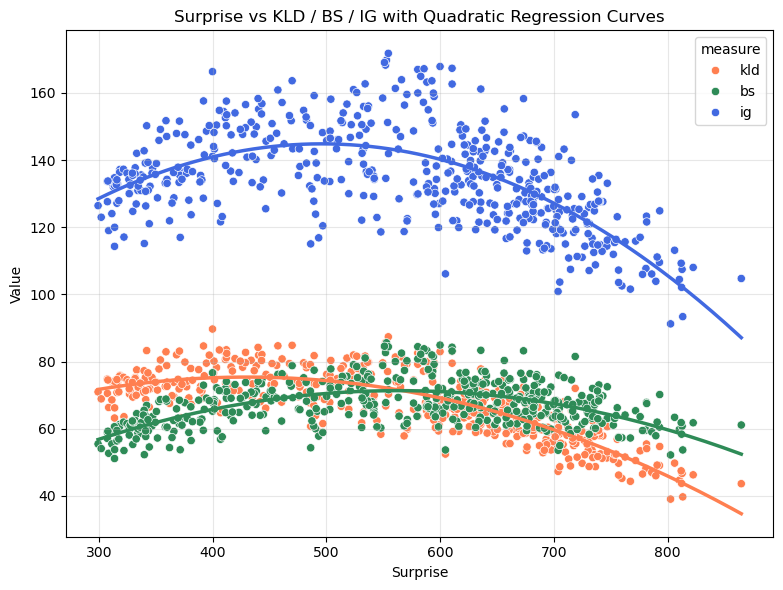

/tmp/ipykernel_647214/206239148.py:275: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


✅ 3次元プロットを保存しました: simulation_results/sim_20251204_033448/ig_vs_surprise_energy_3d_viridis.png
✅ 2次元俯瞰図（奥行き強調）を保存しました: simulation_results/sim_20251204_033448/ig_vs_surprise_energy_2d_heatmap_depth.png


/tmp/ipykernel_647214/206239148.py:371: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


✅ IG vs Energy (Surprise強調) プロットを保存しました: simulation_results/sim_20251204_033448/ig_vs_energy_depth_by_surprise.png


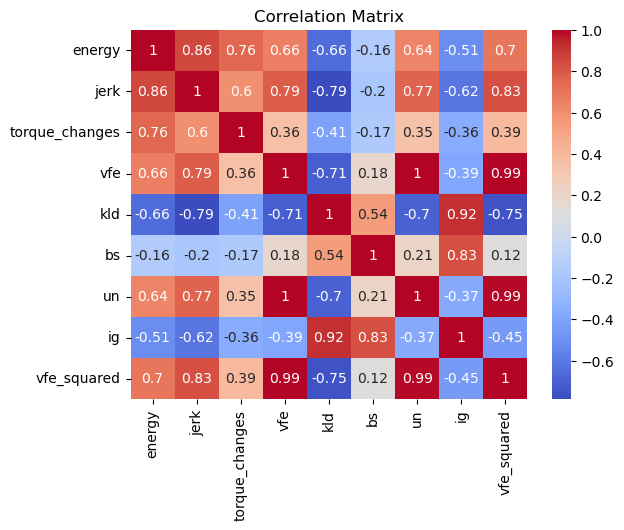

パラメータをJSONとして保存しました。保存先: simulation_results/sim_20251204_033448/metadata.json
フォルダ構造: simulation_results/sim_20251204_033448/metadata.json 他
データフレームを保存しました: simulation_results/sim_20251204_033448/simulation_results.parquet


In [3]:


# いろいろ保存する
import time
import os
import json

# データ分析など
import pandas as pd
import numpy as np

# ylabels = ['vfe', 'kld', 'bs', 'un', ]
df = pd.DataFrame({'energy': energies, 'jerk': jerks, 'torque_changes': torque_changes, 'vfe': vfes, 'kld': klds, 'bs': bss, 'un': uns})
# df['surprise'] = df['vfe'] - df['kld']これは間違い vfeが収束後なのでsurpriseそのもの
df['ig'] = df["kld"] + df["bs"]
ylabels = list(df.columns)

for col in df.columns:
    if col=="qs":
        break
    # 現在の列のデータ型を確認し、もしJAXの配列型（またはオブジェクト型でNumPyに変換可能なもの）であれば変換
    if isinstance(df[col].iloc[0], (np.ndarray, list)):
        # リストやNumPy配列の場合はそのままastypeで型変換
        df[col] = df[col].astype(np.float64)
    elif 'jax' in str(type(df[col].iloc[0])):
        # JAXの型（ArrayImplなど）の場合は、まずNumPy配列に変換してからpandasのシリーズに戻す
        df[col] = np.array(df[col].tolist(), dtype=np.float64)
    else:
        # 既存の数値データ型はそのまま維持
        try:
            df[col] = df[col].astype(np.float64)
        except:
            # 数値でない列（もしあれば）はそのまま
            pass

import statsmodels.api as sm
from statsmodels.formula.api import ols

# ----------------------------------------------------
# 1. 二乗項の作成
# ----------------------------------------------------
df['vfe_squared'] = df['vfe'] ** 2

# 予測用のデータフレーム（滑らかな曲線を描くために細かくデータ点を生成）
vfe_range = np.linspace(df['vfe'].min(), df['vfe'].max(), 200)
pred_df = pd.DataFrame({'vfe': vfe_range, 'vfe_squared': vfe_range ** 2})

# ----------------------------------------------------
# 2. 各目的変数に対する回帰分析の実行と予測値の計算
# ----------------------------------------------------
target_vars = ["kld", "bs", "ig"]
formula = 'Y ~ vfe + vfe_squared'

# 予測値を格納するための新しいDataFrame
predicted_curves = pred_df[['vfe']].copy()

for var in target_vars:
    # 目的変数を 'Y' に一時的にコピーしてモデルを適合
    df_temp = df.rename(columns={var: 'Y'})
    
    # OLSモデルの構築と適合 (Y ~ vfe + vfe_squared)
    reg_model = ols(formula, data=df_temp).fit()
    
    # 予測値の計算
    predicted_curves[var] = reg_model.predict(pred_df)

# ----------------------------------------------------
# 3. 予測値を seaborn 用に melt で縦長データに変換
# ----------------------------------------------------
# 予測値を melt して元のdf_meltと同じ形式にする
predicted_curves_melt = predicted_curves.melt(
    id_vars="vfe", 
    value_vars=target_vars, 
    var_name="measure", 
    value_name="predicted_value"
)


import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 可視化関連
# -----------------------------

# 可視化する変数
variables = ['vfe', 'energy', 'ig']

# 1. すべてのターゲット値を計算し、辞書に統合
all_targets = {}

for var in variables:
    # パーセンタイル値の計算
    p5 = df[var].quantile(0.05)
    p50 = df[var].quantile(0.50)
    p95 = df[var].quantile(0.95)
    
    # P5とP95の算術平均値を計算
    mean_p5_p95 = (p5 + p95) / 2
    
    # 結果を格納
    all_targets[var] = {
        'P5_Low': p5,
        'P50_Mid_Median': p50,
        'P95_High': p95,
        'Mean_P5_P95': mean_p5_p95
    }

print("--- 統合されたターゲット値（中央値と平均値）---")
targets_data = []
for var, values in all_targets.items():
    targets_data.append({
        'Metric': var,
        'P5_Low': values['P5_Low'],
        'P50_Mid_Median': values['P50_Mid_Median'],
        'P95_High': values['P95_High'],
        'Mean_P5_P95': values['Mean_P5_P95']
    })
targets_df = pd.DataFrame(targets_data)
print(targets_df.to_markdown(index=False, floatfmt=".4f"))

# 1. 可視化設定
colors = ['#FF9999', '#99FF99', '#9999FF'] # VFE(赤), Energy(緑), IG(青)

# 2. 3つのサブプロットを持つ図を作成
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 10)) 
plt.subplots_adjust(hspace=0.4) 

# 3. 各変数に対して個別のバイオリンプロットとターゲットラインを作成
for i, var in enumerate(variables):
    ax = axes[i]
    
    # バイオリンプロットを作成
    sns.violinplot(
        y=df[var], 
        ax=ax, 
        color=colors[i], 
        inner='quartile', 
        width=0.3
    )
    
    # ターゲットラインの追加 (P5, P50, P95)
    # Mean_P5_P95を除外したターゲット値のリストを作成
    median_targets = {k: all_targets[var][k] for k in ['P5_Low', 'P50_Mid_Median', 'P95_High']}
    targets_values = list(median_targets.values())
    target_names = ['Low (P5)', 'Mid (P50)', 'High (P95)']

    # P5, P50, P95の水平線を描画
    for level, (name, value) in enumerate(zip(target_names, targets_values)): 
        # 黒の点線で描画
        ax.axhline(
            y=value, 
            color='black', 
            linestyle='--', 
            linewidth=1,
            alpha=0.8,
            label=f'{name} Target: {value:.3f}' if level == 0 else "" 
        )
        # ラベルをプロットの右側に配置
        ax.text(
            ax.get_xlim()[1] * 0.95, 
            value,
            f'{name}', 
            ha='right', 
            va='center', 
            fontsize=9, 
            bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1}
        )
    
    # --- 4. Mean_P5_P95 の追加可視化 ---
    mean_value = all_targets[var]['Mean_P5_P95']
    
    # 赤色の破線で Mean_P5_P95 を描画
    ax.axhline(
        y=mean_value, 
        color='red', 
        linestyle='-.', # チェーン線
        linewidth=1.5,
        alpha=0.8,
        label=f'Mean Target: {mean_value:.3f}'
    )
    # Meanターゲットのラベルをプロットの左側に配置
    ax.text(
        ax.get_xlim()[0] * 0.95, # x位置 (プロット左側)
        mean_value,                    # y位置
        f'Mean Target', 
        ha='left', 
        va='center', 
        color='red',
        fontsize=9, 
        bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1}
    )
    
    # タイトルとラベルを設定
    ax.set_title(f'Distribution and Targets for {var}', fontsize=12)
    ax.set_ylabel(var, fontsize=10)
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.6)

# 5. 図の保存
plt.tight_layout()
plot_filename_robust_targets_violinplots = "robust_targets_violinplots_with_mean.png"
plot_path_robust_targets_violinplots = os.path.join(run_dir, plot_filename_robust_targets_violinplots)
plt.savefig(plot_path_robust_targets_violinplots, dpi=300)
plt.close(fig)

print(f"✅ 平均値ターゲットを含むバイオリンプロットを保存しました: {plot_path_robust_targets_violinplots}")
plt.show()




# seaborn用に melt で縦長データに変換
df_melt = df.melt(id_vars="vfe", value_vars=["kld", "bs", "ig"], var_name="measure", value_name="value")

custom_palette = {
    'kld': 'coral',    # 赤系
    'bs': 'seagreen',  # 緑系
    'ig': 'royalblue' # 青系
}

plt.figure(figsize=(8, 6))
plt.xlabel("Surprise")
plt.ylabel("Value")
plt.title("Surprise vs KLD / BS / IG with Quadratic Regression Curves")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# **A. 散布図のプロット (元のデータ)**
sns.scatterplot(data=df_melt, 
                x="vfe", 
                y="value", 
                hue="measure", 
                palette=custom_palette, 
                alpha=1.0,
                legend=True) # 凡例は散布図と線で共有
# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename = "surprise_vs_ig.png"
plot_path = os.path.join(run_dir, plot_filename)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存

# **B. 重回帰曲線のプロット**
# 予測曲線のデータに対して線グラフを描画
sns.lineplot(data=predicted_curves_melt, 
             x="vfe", 
             y="predicted_value", 
             hue="measure", 
             palette=custom_palette, 
             linestyle='-',
             linewidth=2.5,
             legend=False) # 凡例が重複しないように線グラフ側は非表示


# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename_reg = "surprise_vs_ig_reg.png"
plot_path = os.path.join(run_dir, plot_filename_reg)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存

# 一応表示
plt.show()


# energyも含めた3dプロット# 1. データの準備
x_data = df['vfe']    # X軸: Surprise
y_data = df['energy'] # Y軸: Energy (3Dの奥行き)
z_data = df['ig']     # Z軸: Information Gain (3Dの高さ 兼 2D/3Dの色)

# 2. カラーマップと色の計算
# 💡 ヒートマップによく使われる配色: Viridisを採用 (青 → 緑/黄 → 黄色/オレンジ)
# Jetも選択肢ですが、現代ではViridisが推奨されます
cmap_name = 'viridis' 
cmap = plt.cm.get_cmap(cmap_name) 
# igの値を正規化して色を割り当てる (0-1の範囲にスケーリング)
normalize = plt.Normalize(z_data.min(), z_data.max())
colors = cmap(normalize(z_data))


# =========================================================
# A. 3次元プロットの作成と保存
# =========================================================
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d') # 3Dプロジェクションを設定

# 散布図のプロット
scatter_3d = ax_3d.scatter(x_data, 
                          y_data, 
                          z_data, 
                          c=colors,        # 正規化された色配列を渡す
                          marker='o', 
                          s=30,            
                          alpha=0.8)

# ラベルとタイトルの設定
ax_3d.set_xlabel("Surprise (VFE)", fontsize=12)
ax_3d.set_ylabel("Energy", fontsize=12) # 奥行き軸
ax_3d.set_zlabel("Information Gain (IG)", fontsize=12) # 高さ軸
ax_3d.set_title(f"3D Plot: IG vs Surprise and Energy (Color Map: {cmap_name})", fontsize=14)

# カラーバーの追加
cbar_3d = fig_3d.colorbar(scatter_3d, ax=ax_3d, pad=0.1)
cbar_3d.set_label('Information Gain (IG) Value', fontsize=10)

plt.tight_layout()
plot_filename_3d = f"ig_vs_surprise_energy_3d_{cmap_name}.png"
plot_path_3d = os.path.join(run_dir, plot_filename_3d)
plt.savefig(plot_path_3d, dpi=300) 
plt.close(fig_3d)
print(f"✅ 3次元プロットを保存しました: {plot_path_3d}")

# =========================================================
# B. 2次元ヒートマップ（俯瞰図）の作成と保存 (ig値によるサイズ・描画順序の調整)
# =========================================================
fig_2d, ax_2d = plt.subplots(figsize=(8, 8))

# 1. サイズと描画順序のためのデータの準備
# igの最小値と最大値を基準に、マーカーサイズを計算 (例: 最小サイズ20, 最大サイズ200)
min_size = 20
max_size = 200
size_range = max_size - min_size

# ig値を正規化してサイズを計算
normalized_ig = (z_data - z_data.min()) / (z_data.max() - z_data.min())
marker_sizes = normalized_ig * size_range + min_size

# 2. 描画順序の決定 (igが大きいものほど手前/後から描画する)
# NumPyのargsortを使って、igの昇順インデックスを取得
sort_indices = np.argsort(z_data.values)

# 3. ソートされた順序でプロット
# igの小さい順から描画し、大きいものが上書きされるようにする
scatter_2d = ax_2d.scatter(x_data.iloc[sort_indices],
                          y_data.iloc[sort_indices],
                          c=z_data.iloc[sort_indices], # 色
                          cmap=cmap, 
                          norm=normalize, 
                          s=marker_sizes[sort_indices], # サイズ
                          alpha=0.7, 
                          edgecolors='black', # エッジをつけて立体感を強調
                          linewidths=0.5)

# 4. ラベルとタイトルの設定
ax_2d.set_xlabel("Surprise (VFE)", fontsize=12)
ax_2d.set_ylabel("Energy", fontsize=12)
ax_2d.set_title(f"2D Top View: IG by Surprise and Energy (Depth by IG Size)", fontsize=14)
ax_2d.grid(True, alpha=0.3)

# 5. カラーバーの追加
cbar_2d = fig_2d.colorbar(scatter_2d, ax=ax_2d)
cbar_2d.set_label('Information Gain (IG) Value', fontsize=10)

plt.tight_layout()
plot_filename_2d = f"ig_vs_surprise_energy_2d_heatmap_depth.png"
plot_path_2d = os.path.join(run_dir, plot_filename_2d)
plt.savefig(plot_path_2d, dpi=300) 
plt.close(fig_2d)

print(f"✅ 2次元俯瞰図（奥行き強調）を保存しました: {plot_path_2d}")

# -----------------------------

# 1. データの再割り当て（軸の入れ替え）
x_data_new = df['ig']       # X軸: Information Gain (IG)
y_data_new = df['energy']   # Y軸: Energy
color_size_data = df['vfe'] # 色とサイズ: Surprise (VFE)

# 2. カラーマップとサイズの計算（Surpriseに基づいて計算）
cmap_name = 'viridis' 
cmap = plt.cm.get_cmap(cmap_name) 

# Surprise (VFE) の値を正規化
normalize_vfe = plt.Normalize(color_size_data.min(), color_size_data.max())
colors_vfe = cmap(normalize_vfe(color_size_data))

# サイズの計算 (Surpriseが大きいほど大きく、手前に見えるように)
min_size = 20
max_size = 200
size_range = max_size - min_size
normalized_vfe = (color_size_data - color_size_data.min()) / (color_size_data.max() - color_size_data.min())
marker_sizes_vfe = normalized_vfe * size_range + min_size

# 3. 描画順序の決定 (Surpriseが大きいものほど手前/後から描画する)
sort_indices_vfe = np.argsort(color_size_data.values)


# =========================================================
# D. IG vs Energy プロットの作成と保存 (Surprise強調)
# =========================================================
fig_d, ax_d = plt.subplots(figsize=(8, 8))

# ソートされた順序でプロット
scatter_d = ax_d.scatter(x_data_new.iloc[sort_indices_vfe],
                         y_data_new.iloc[sort_indices_vfe],
                         c=color_size_data.iloc[sort_indices_vfe], # 色
                         cmap=cmap, 
                         norm=normalize_vfe, 
                         s=marker_sizes_vfe[sort_indices_vfe], # サイズ
                         alpha=0.7, 
                         edgecolors='black', # エッジをつけて立体感を強調
                         linewidths=0.5)

# 4. ラベルとタイトルの設定
ax_d.set_xlabel("Information Gain (IG)", fontsize=12)
ax_d.set_ylabel("Energy", fontsize=12)
ax_d.set_title(f"IG vs Energy (Depth & Color by Surprise/VFE)", fontsize=14)
ax_d.grid(True, alpha=0.3)

# 5. カラーバーの追加 (Surpriseの値を示す)
cbar_d = fig_d.colorbar(scatter_d, ax=ax_d)
cbar_d.set_label('Surprise (VFE) Value', fontsize=10)

plt.tight_layout()
plot_filename_d = f"ig_vs_energy_depth_by_surprise.png"
plot_path_d = os.path.join(run_dir, plot_filename_d)
plt.savefig(plot_path_d, dpi=300) 
plt.close(fig_d)

print(f"✅ IG vs Energy (Surprise強調) プロットを保存しました: {plot_path_d}")
plt.show()


# もろもろの相関係数
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename_corr = "corr_mat.png"
plot_path = os.path.join(run_dir, plot_filename_corr)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存
plt.show()



# for label in ylabels:
#     sns.scatterplot(data=df, x='energy', y=label)
#     plt.title(f'Scatter plot between Energy and {label}')
#     plt.show()

# for label in ylabels:
#     sns.scatterplot(data=df, x='jerk', y=label)
#     plt.title(f'Scatter plot between Jerk and {label}')
#     plt.show()
    


# パラメータを整理し、他のメタデータと統合する
metadata = {
    "run_id": unique_id,
    "environment_settings": {
        "dof": dof,
        "velocity_scale": velocity_scale,
        "effort_scale": effort_scale,
        "fps": fps,
        "sec": sec,
        "time_steps": time_steps,
        "dt": dt,
        # "start_joint_angle": start,
        # "end_joint_angle": end,
        "num_knots": num_knots
    },
    "generative_model_settings": {
        "bin_M": bin_M,
        "eps_tolerance": eps,
        "variance_a": var_a,
        "variance_b": var_b,
        "variance_min": varmin,
        "variance_max": varmax,
        "n_divisions": n_divisions,
        "num_iterations": num_iter,
        "num_observations": num_obs
    },
    # 回帰分析の要約結果を格納
    # "regression_summary": regression_summary
}

# JSONファイルとして保存
metadata_path = os.path.join(run_dir, "metadata.json")
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)

print(f"パラメータをJSONとして保存しました。保存先: {metadata_path}")
print(f"フォルダ構造: {run_dir}/metadata.json 他")

# Parquet形式で保存 (推奨)
df_path = os.path.join(run_dir, "simulation_results.parquet")
# df.to_parquet(df_path, index=False)
# CSV形式で保存 (汎用性)
df.to_csv(os.path.join(run_dir, "simulation_results.csv"), index=False)
print(f"データフレームを保存しました: {df_path}")

# qssを保存
qs_path = os.path.join(run_dir, "qs_object.pkl")
with open(qs_path, 'wb') as f:
    pickle.dump(qss, f)

# const_beliefsを保存
beliefs_path = os.path.join(run_dir, "const_beliefs.pkl")
with open(beliefs_path, 'wb') as f:
    pickle.dump(opt.const_beliefs, f)


# 単回帰分析
# x=vfe, y=kld, bs, ig

In [4]:
# ここではP50をターゲットとし、P5とP95を正規化範囲として使用します。
# Sim: 500/500 | Percep. time: 2.05s: 100%
#  500/500 [17:20<00:00,  1.91s/it]
# --- 統合されたターゲット値（中央値と平均値）---
# | Metric   |   P5_Low |   P50_Mid_Median |   P95_High |   Mean_P5_P95 |
# |:---------|---------:|-----------------:|-----------:|--------------:|
# | vfe      | 326.2323 |         592.7926 |   755.7112 |      540.9717 |
# | energy   | 196.7236 |        2314.1308 | 14981.4484 |     7589.0860 |
# | ig       | 111.1406 |         134.1505 |   158.9401 |      135.0403 |

ig_min_range = df['ig'].quantile(0.05)
ig_max_range = df['ig'].quantile(0.95)
ig_target_value = df['ig'].quantile(0.95)

energy_min_range = df['energy'].quantile(0.05)
energy_max_range = df['energy'].quantile(0.95)
energy_target_value = df['energy'].quantile(0.05)

targets = {
    "ig": {"target": ig_target_value, "min": ig_min_range, "max": ig_max_range},
    "energy": {"target": energy_target_value, "min": energy_min_range, "max": energy_max_range},
    "irrelevant_tag": {"target": 100, "min": 0, "max": 200} # 無視されるタグの例
}

best_cost, best_particle, best_qs = opt.optimize(
    targets=targets
    # torque_change=1.0e-4, #~6.0e+4
    # jerk=1.0e-2, #~8.0e+3
    # iters=iters,
    # end_penalty=1.0e2, # ~3.0e+-1
    # temporal_approach_cost=1.0e1 # ~2.0e-1
    )

2025-12-04 04:03:33,740 - pyswarms.single.global_best - INFO - Optimize for 1 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.9}
pyswarms.single.global_best:   0%|          |0/1


UnboundLocalError: local variable 'current_values' referenced before assignment

In [ ]:

# 観測させて各指標の合計をストック
opt.env.computeAllobs(qs, dt)
opt.agent.reset()
# opt.agent.run_perception(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)
opt.agent.bayse_estimate(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)

opt.agent.plot_fe_all(vfe=True) 
opt.agent.plot_belief_and_qs_history()
